# PAM50 Subtypes

### Luminal A
- usually lower-grade (well-differentiated, slower growing)
- more granular (cells look more like breast tissue)
- ER+ and / or PR+ (often HER2 negative)
- good prognosis

### Luminal B
- higher grade and faster-growing than Luminal A
- ER+ and/or PR+, but often with lower expression levels
- can be HER2-positive or HER2-negative
- higher proliferation rate (e.g., higher Ki-67) than Luminal A

### Basal like
- high-grade (fast-growing, aggressive, poor differentiation)
- almost always triple negative breast cancer (TNBC = HER-, PR-, HER2-)
- often seen in younger women, BRCA1 carriers
- associated with desmoplasia and stroma-high tumors

### HER2-enriched
- high-grade and aggressive
- driven by HER2 amplification/overexpression
- typically ER- and PR-negative
- high proliferation rate (high Ki-67)

### Normal-like
- gene expression profile most similar to normal breast tissue
- often ER+ and/or PR+, but HER2-negative
- generally lower grade and slower-growing
- good prognosis, similar to Luminal A

Tiles of different histological subtypes to understand how they differ in histology.

In [4]:
import zipfile
from PIL import Image
import io
import matplotlib.pyplot as plt

In [9]:
lumA_path = '/mnt/bulk-saturn/maralampert/genhist/data/BRCA-tumor-tiles/TCGA-A2-A0CS-01Z-00-DX1.3986B545-63E8-4727-BCC1-701DE947D1FB.1b35dffcb3eb136ca9a07ad10f1255dada7e5c82b959b5a3d0e84147183bb9aa.zip' # stage IV
lumB_path = '/mnt/bulk-saturn/maralampert/genhist/data/BRCA-tumor-tiles/TCGA-AC-A62V-01Z-00-DX1.2D8994FD-58B8-43C1-B99D-AA964E7DFD60.78f57b4a64d2e2a72c3d1f95ef520d6cfcfc655cf8b82bca6ab841334117df91.zip' # stage IV
basal_path = '/mnt/bulk-saturn/maralampert/genhist/data/BRCA-tumor-tiles/TCGA-A2-A1G1-01Z-00-DX1.E52A474F-DE13-41CF-94D4-D00BAC46ECF4.e09954e4d36ef0588de607ebcad7a6fa26c81dd2653ef3b372f76b3a4e834753.zip' # stage IIB
her2_path = "/mnt/bulk-saturn/maralampert/genhist/data/BRCA-tumor-tiles/TCGA-A8-A08J-01Z-00-DX1.4607286A-033B-4C44-8306-50DB9C596166.7fba9af7481f3dc22ec131eeb371c321d87cc0480c732fa3e6a905cf414a2c4b.zip" # stage IV
normal_path = '/mnt/bulk-saturn/maralampert/genhist/data/BRCA-tumor-tiles/TCGA-AC-A2FK-01Z-00-DX1.033F3C27-9860-4EF3-9330-37DE5EC45724.f31fe26d1a5709bcce3a98f3073fd3a8164b1f77d7f678c009c5baac3cc8dead.zip' # stage IIC

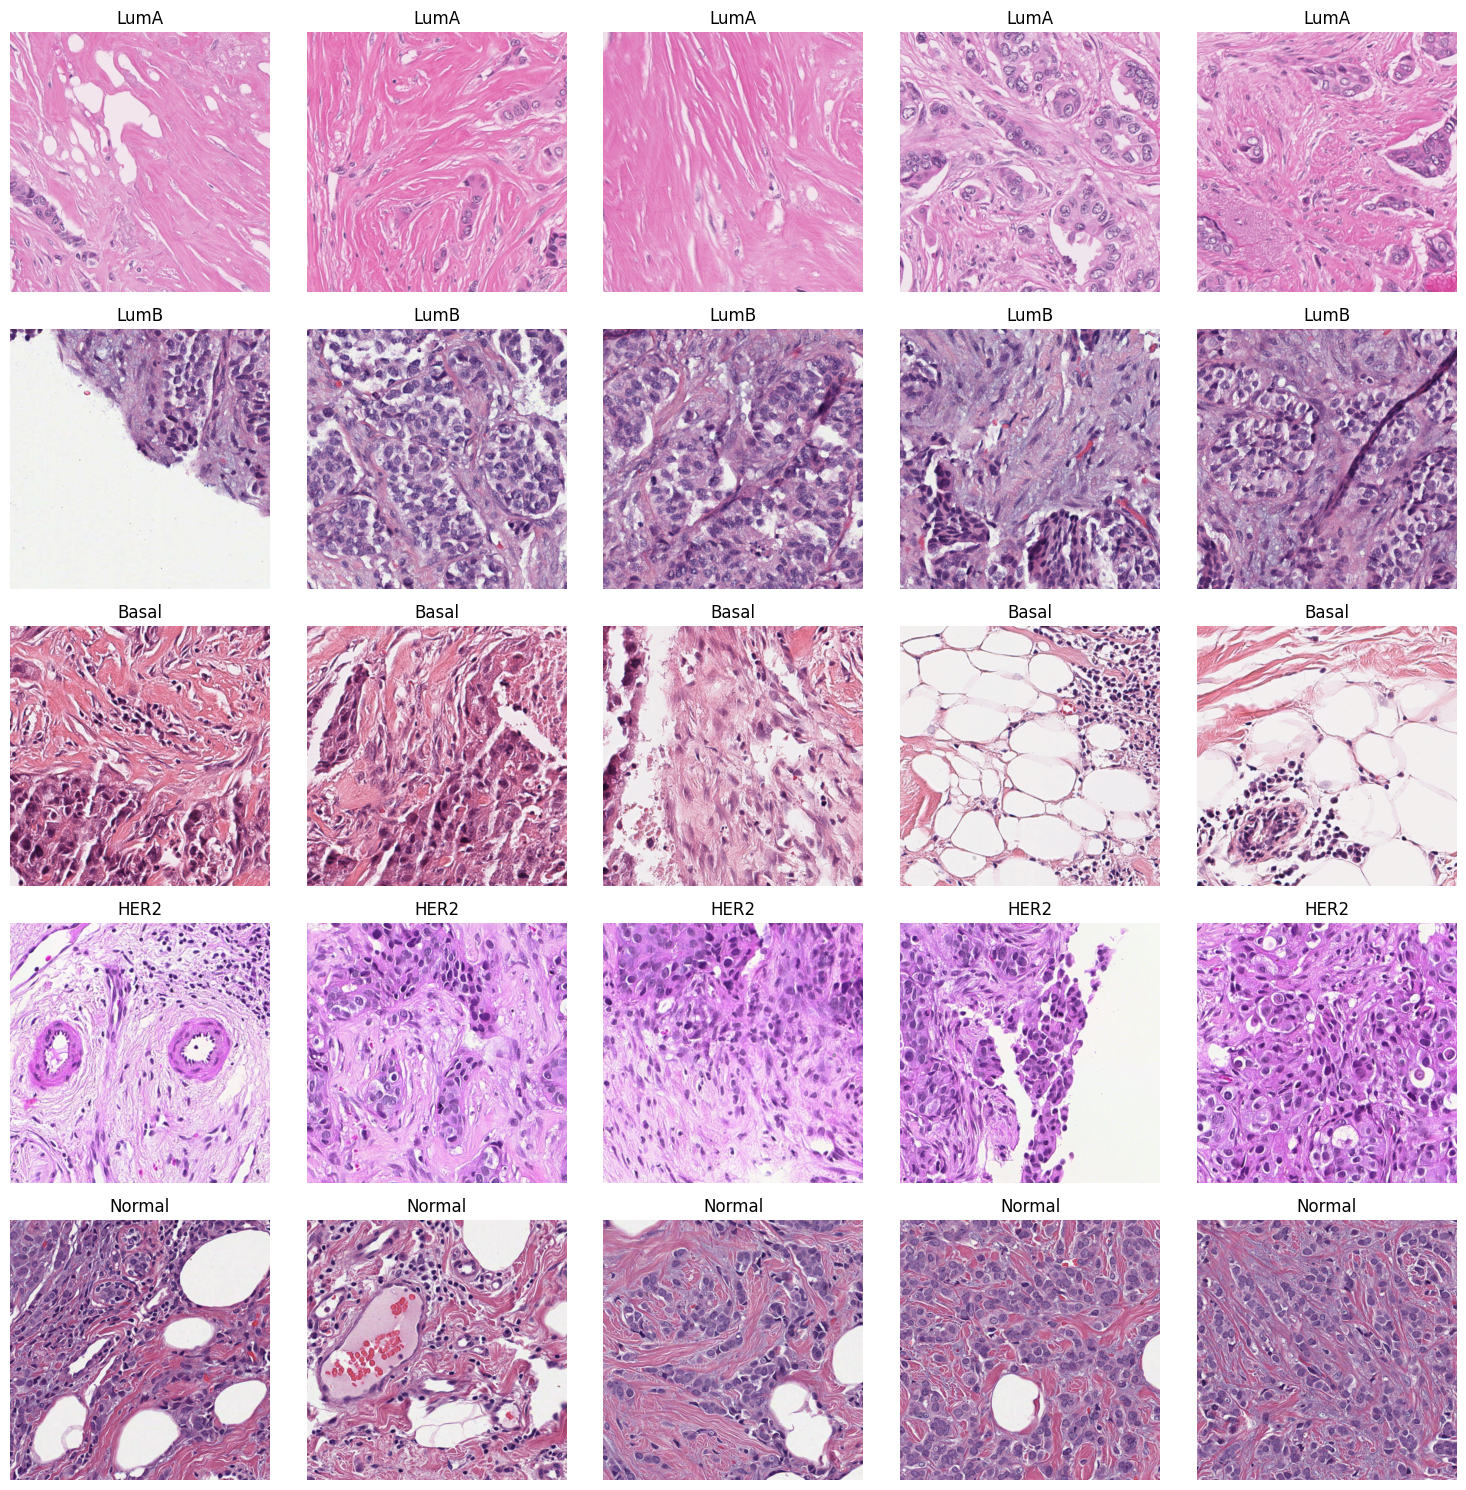

In [10]:
# unzip the zip files and display 5 png files from each zip in a grid of 5x5 and write labels below each image
zip_paths = [lumA_path, lumB_path, basal_path, her2_path, normal_path]
labels = ['LumA', 'LumB', 'Basal', 'HER2', 'Normal']

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for i, zip_path in enumerate(zip_paths):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        png_files = [f for f in zip_ref.namelist() if f.endswith('.png')]
        for j in range(5):
            if j < len(png_files):
                with zip_ref.open(png_files[j]) as file:
                    img_data = file.read()
                    img = Image.open(io.BytesIO(img_data))
                    axes[i, j].imshow(img)
                    axes[i, j].set_title(labels[i])
                    axes[i, j].axis('off')
plt.tight_layout()
plt.show()  

| Feature                     | Luminal A                              | Luminal B                                                    | Basal‑like                                                                 | HER2‑enriched                     | Normal‑like                                            |
|-----------------------------|----------------------------------------|------------------------------------------------------------|--------------------------------------------------------------------------|-----------------------------------|--------------------------------------------------------|
| **Overall Grade**           | Low Grade                              | Intermediate to High Grade                                 | High Grade                                                               | High Grade                        | Low Grade                                              |
| **Architectural Pattern**   | Well‑formed, open tubules; low nuclear grade. | Less tubular, more solid nests; higher nuclear grade.      | Pushing borders, often with central necrosis.                           | Solid nests or sheets of cells.   | Well‑formed, open tubules; similar to Luminal A.       |
| **Cytological Features**    | Small, uniform, regular nuclei; low pleomorphism. | More variation in nuclear size/shape (pleomorphism); larger nuclei. | High pleomorphism; often with prominent nucleoli.                      | Marked pleomorphism; large, irregular nuclei. | Small, uniform nuclei; low pleomorphism.              |
| **Mitotic Rate / Proliferation** | Low mitotic rate; low Ki‑67 index (<14%). | Higher mitotic rate; higher Ki‑67 index (often >14%).      | Very high mitotic rate; high Ki‑67 index.                               | High mitotic rate; high Ki‑67 index. | Low mitotic rate; low Ki‑67 index.                     |
| **Key IHC Markers**         | **ER+**, **PR+**, **HER2‑**             | **ER+** and/or **PR+**, **HER2+** or **HER2‑**, **Ki‑67 High** | **Triple‑Negative** (ER‑, PR‑, HER2‑), **CK5/6+**, **EGFR+**               | **HER2+**, **ER‑**, **PR‑**        | **ER+**, **PR+**, **HER2‑**                             |
| **Special Features**       | –                                      | –                                                          | Desmoplasia (dense stroma), prominent lymphocytic infiltrate.          | –                                 | Often a result of low tumor cellularity in the sample; clinical significance is debated. |